<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 2: 기본 모델링**

## **미션 설명**

- 이번 단계에서는 다음과 같이 2개의 미션을 수행합니다.

### 미션 6: 전처리

- 다음과 같은 이유로 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
    - 0점은 '매우 불만족'보다 낮은 점수가 아니라 '해당 없음'을 의미하는 경우가 많습니다.
    - 만약 0, 1, 2, 3, 4, 5 그대로 넣으면, 모델은 0을 1보다 더 나쁜 것으로 학습하여 예측에 오류가 생길 수 있습니다.
    - 만족도 1점과 2점의 차이가 4점과 5점의 차이와 물리적으로 동일하지 않습니다.
    - 가변수화를 하면 모델이 각 점수를 독립적으로 학습할 수 있어 더 유연한 모델이 될 것입니다.
- 모델링을 위해 x, y로 분리하고 학습용/검증용 데이터로 분리합니다.
- 스케일링을 수행합니다.

### 미션 7: 모델링

- 4개 이상의 딥러닝 모델을 만들어 성능을 확인합니다.
- 모델 이름은 model1, model2, model3, model4...로 구분합니다.
- 마지막 모델의 경우 예측 성능을 높이기 위해 다양한 시도를 해봅니다.
- 가장 성능이 좋은 모델을 저장합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [93]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [94]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [95]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 데이터 불러오기

- 이전 과정에서 저장한 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'data.csv' --> data
    

In [96]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

In [97]:
# 크기(행, 열) 확인
print(data.shape)

(19278, 23)


In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

## **2. 미션 6: 전처리**

- 결측치 처리는 이전 과정에서 완료가 된 상태입니다.
- 딥러닝 모델링을 위해 필요한 전처리를 수행합니다.

### (1) 가변수화

- 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
- 대상 변수는 'Inflight wifi service'부터 'Cleanliness'까지 14개 입니다.
- 일관된 가변수화 결과를 위해 Category 형 변수로 변환합니다.

In [99]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
# 카테고리컬 범주형 변수로 바꿔버릴 거임
# 왜냐하면 0-5 리커트로 들어가있기 때문 / 근데 0은 해당없음이기에 의미없음
# 근데 검증용으로 쓰다보면 2-5
# 이런식으로 비는 척도가 생길 수도있음
# 그래서 가변수화 하면 6개 열이 생기니까
# 그리고 2-5면 4개열이 생기게되니까
# 학습 데이터와 검증 데이터와 열 개수가 달라져버리게됨


# Category 형 변수로 변환
for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

# 가변수화
data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)
# drop_first 옵션이 첫번재 0을 없애준것

#data별 가변수화

# 확인
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 79 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Gender                               19278 non-null  int64  
 1   Customer Type                        19278 non-null  int64  
 2   Age                                  19278 non-null  float64
 3   Type of Travel                       19278 non-null  int64  
 4   Class                                19278 non-null  int64  
 5   Flight Distance                      19278 non-null  int64  
 6   Departure Delay in Minutes           19278 non-null  int64  
 7   Arrival Delay in Minutes             19278 non-null  float64
 8   Satisfaction                         19278 non-null  int64  
 9   Inflight wifi service_1              19278 non-null  int64  
 10  Inflight wifi service_2              19278 non-null  int64  
 11  Inflight wifi service_3     

### (2) 데이터 분할

- x, y를 분리한 후 학습용/검증용 데이터를 8:2로 분리합니다.

In [100]:
target = 'Satisfaction'
x = data.drop(target, axis=1)
y = data.loc[:, target]

In [101]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1)

### (3) 스케일링

- MinMaxScaler()를 사용해 스케일링을 수행합니다.

In [102]:
# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3. 미션 7: 모델링**

- 다음과 같이 4개 이상의 모델을 만들고 성능을 확인합니다.
    - 모델 1: Base line 모델(Hidden Layer 없이 모델 생성)
    - 모델 2: 복잡한 모델 생성(최소 5개 이상의 Hidden Layer 추가)
    - 모델 3 ~ n: 모델 튜닝(학습률, epoch 조정, Dropout, Early Stopping 등 모델 성능을 높이기 위한 다양한 시도)


### (1) 모델 1

- 우선 모델을 선언합니다.

In [103]:
# 베이스 모델
# 모델 세션 정리
clear_session()

# 입력 피쳐 수
nfeatures = x.shape[1]

# 시퀀셜 모델 선언
model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(1)
])

# 모델 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            79 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [104]:
# 학습 설정 => 분류모델이기에 정확성으로
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [105]:
# 이미 나눈 x_val, y_val을 검증셋으로 직접 전달
hist = model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=32, # 보통 32나 64 설정
                 validation_data=(x_val, y_val), # 분리해둔 데이터를 그대로 사용
                 verbose=1) # 학습 과정을 보기 위해 1로 설정 추천

Epoch 1/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5257 - loss: 4.2445 - val_accuracy: 0.8001 - val_loss: 0.8085
Epoch 2/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8229 - loss: 0.7247 - val_accuracy: 0.8457 - val_loss: 0.6093
Epoch 3/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8485 - loss: 0.6167 - val_accuracy: 0.8548 - val_loss: 0.5658
Epoch 4/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.5235 - val_accuracy: 0.8680 - val_loss: 0.4862
Epoch 5/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8856 - loss: 0.4573 - val_accuracy: 0.8838 - val_loss: 0.4067
Epoch 6/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8964 - loss: 0.4086 - val_accuracy: 0.9035 - val_loss: 0.3898
Epoch 7/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9089 - loss: 0.3925 - val_accuracy: 0.9152 - val_loss: 0.3831
Epoch 8/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9088 - loss: 0.3276 - val_accuracy: 0.

- 학습 곡선을 확인합니다.

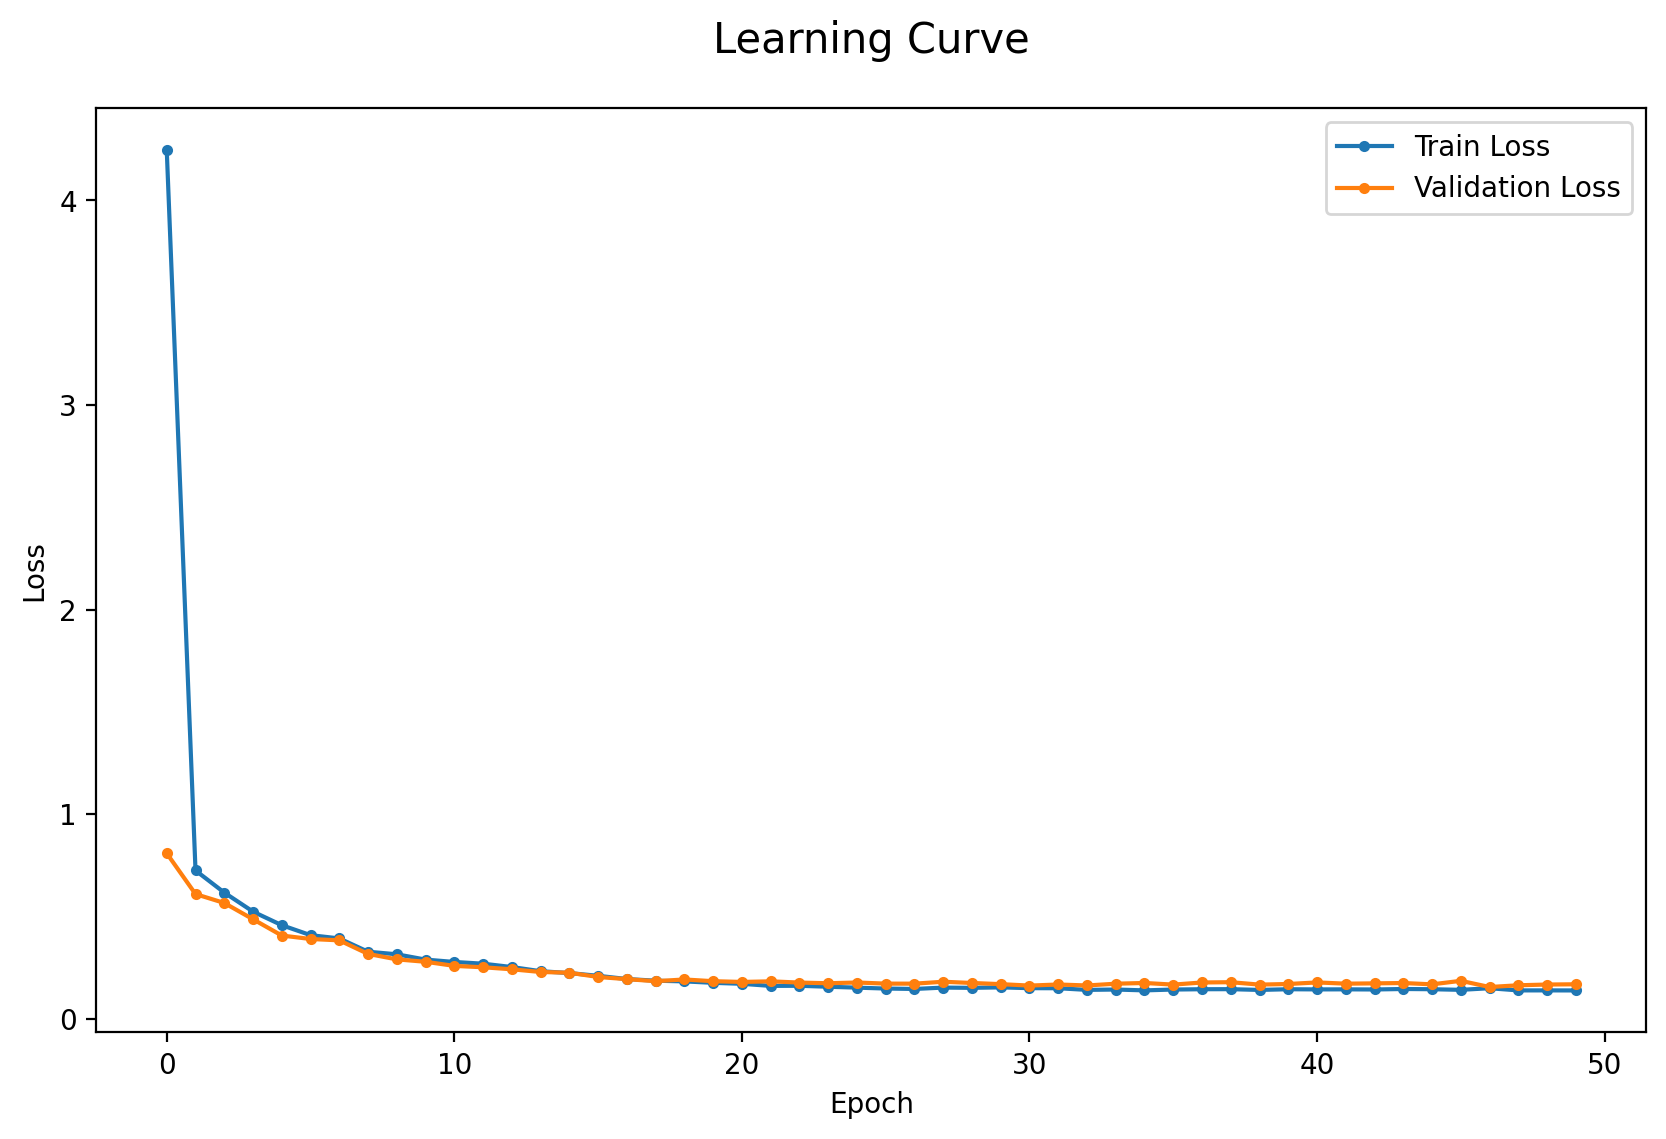

In [106]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [107]:
# 예측
y_pred = model.predict(x_val)
print(y_pred[:5])

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[2.3783896]
 [1.9240966]
 [1.4704043]
 [1.1802495]
 [1.4532433]]


In [108]:
# 확률값 --> 0, 1 변환
y_pred = (y_pred > 0.5).astype('int')

# y_pred = np.where(y_pred > 0.5, 1, 0)

In [109]:
# 성능 평가
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76       358
           1       0.97      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.89      0.85      0.87      3856
weighted avg       0.96      0.96      0.96      3856



<Axes: >

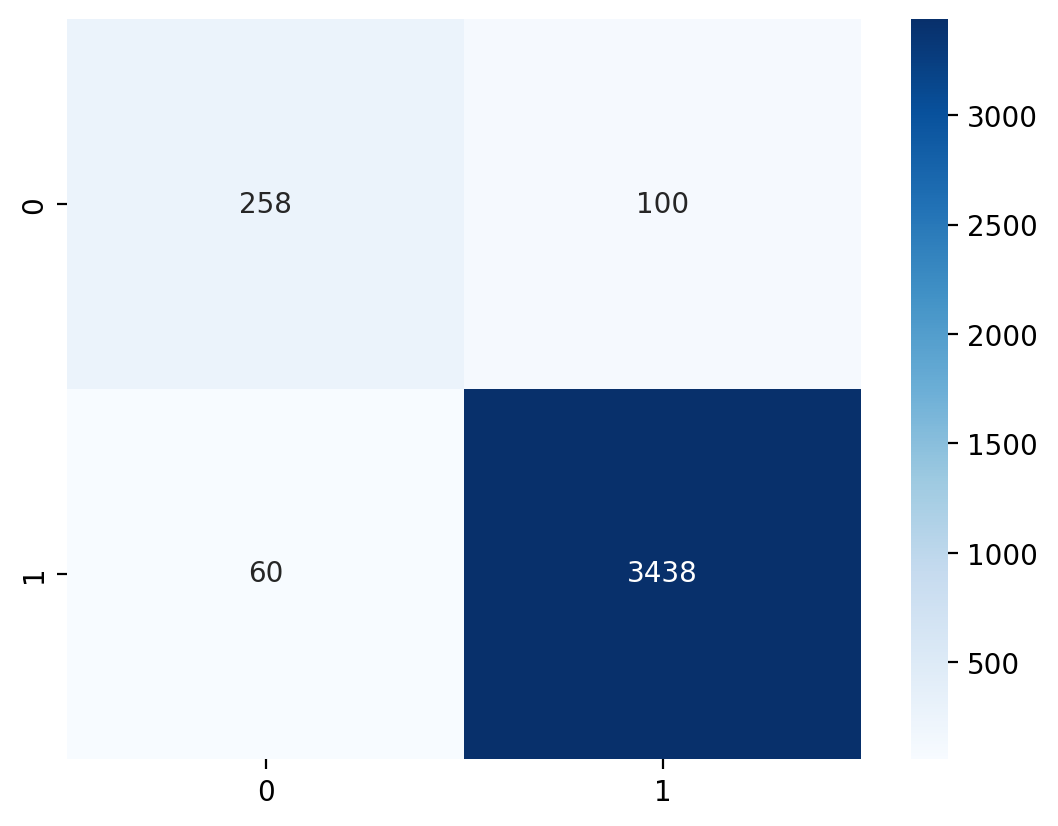

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')


### (2) 모델 2

- 모델을 선언합니다.

In [111]:
# 베이스 모델 + @
# 모델 세션 정리
clear_session()

# 입력 피쳐 수
nfeatures = x.shape[1]

# 시퀀셜 모델 선언
model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [112]:
# 학습 설정 => 분류모델이기에 정확성으로
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

- 학습 곡선을 확인합니다.

In [113]:
# 이미 나눈 x_val, y_val을 검증셋으로 직접 전달
hist = model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=32, # 보통 32나 64 설정
                 validation_data=(x_val, y_val), # 분리해둔 데이터를 그대로 사용
                 verbose=1) # 학습 과정을 보기 위해 1로 설정 추천

Epoch 1/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9448 - loss: 0.1419 - val_accuracy: 0.9608 - val_loss: 0.1070
Epoch 2/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9621 - loss: 0.0994 - val_accuracy: 0.9671 - val_loss: 0.0944
Epoch 3/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9687 - loss: 0.0863 - val_accuracy: 0.9684 - val_loss: 0.0906
Epoch 4/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9708 - loss: 0.0791 - val_accuracy: 0.9699 - val_loss: 0.0816
Epoch 5/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 0.0747 - val_accuracy: 0.9689 - val_loss: 0.0865
Epoch 6/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0706 - val_accuracy: 0.9717 - val_loss: 0.0831
Epoch 7/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0678 - val_accuracy: 0.9663 - val_loss: 0.0897
Epoch 8/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9730 - loss: 0.0674 - val_accuracy: 0.

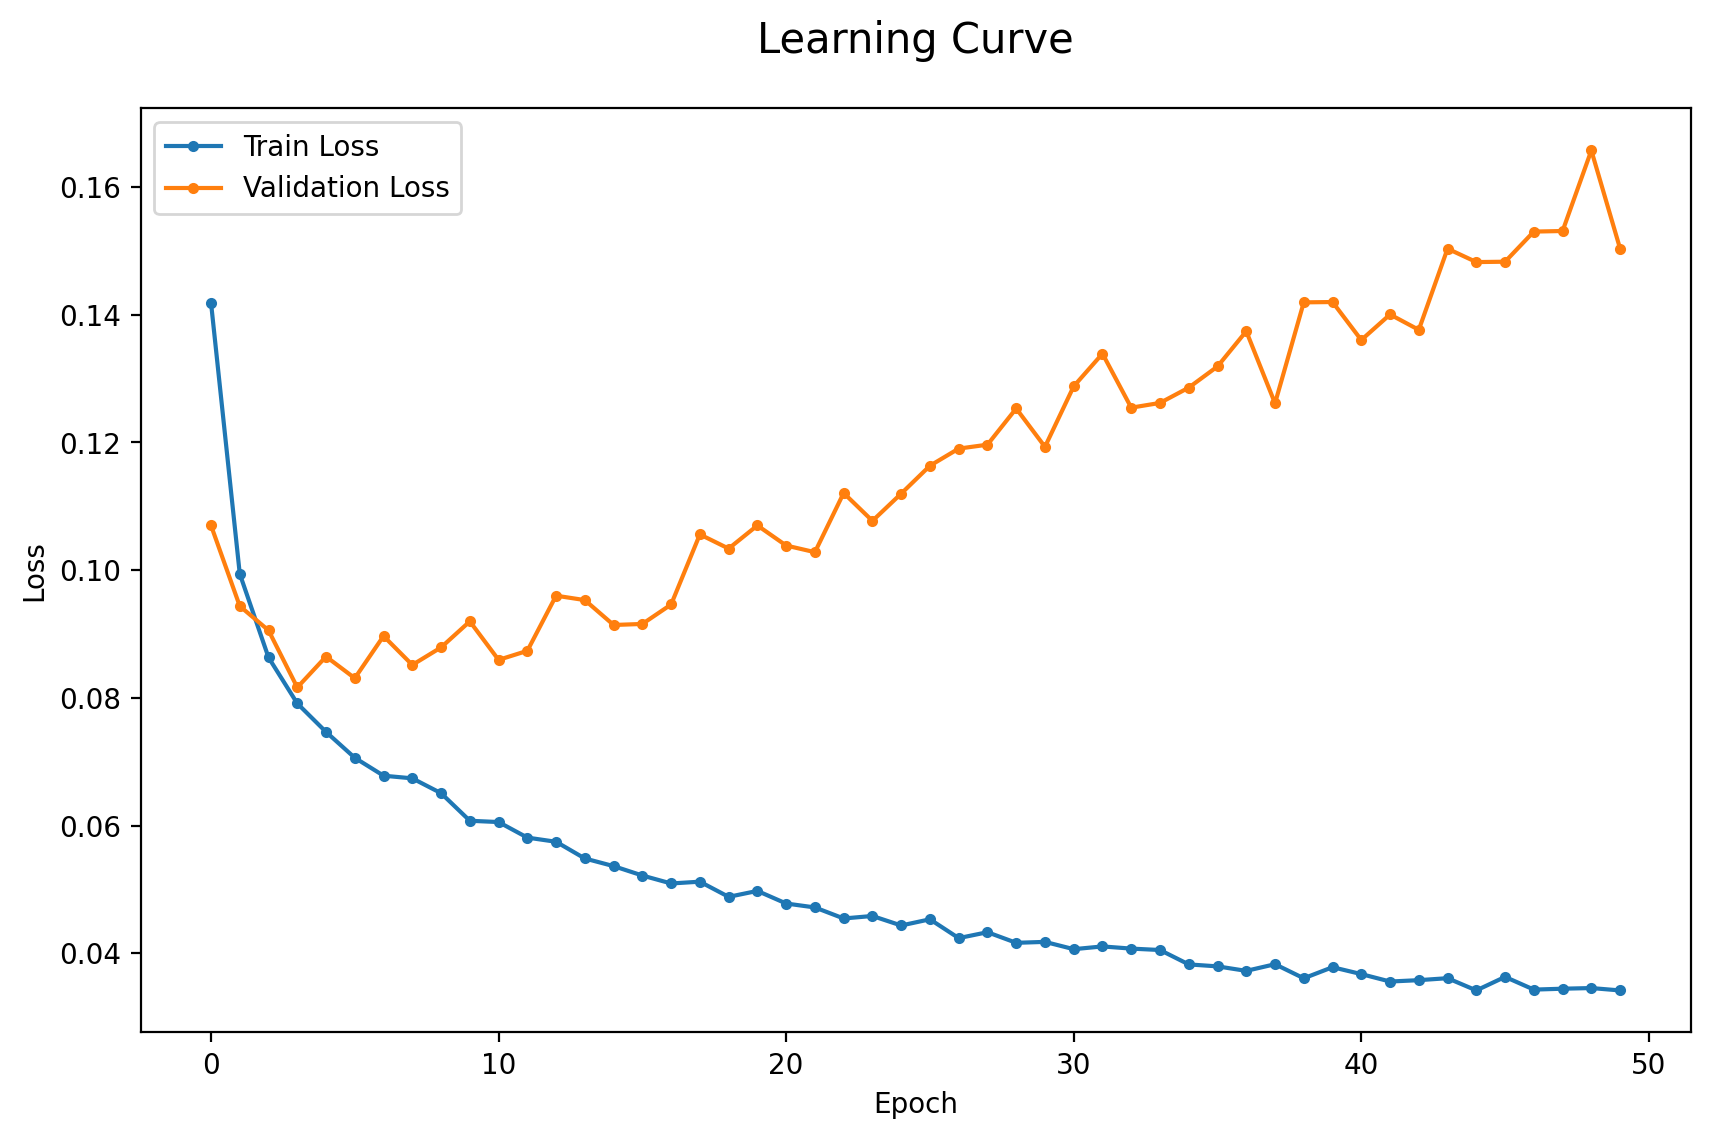

In [114]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [115]:
# 예측
y_pred = model.predict(x_val)
print(y_pred[:5])

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1.        ]
 [0.9999971 ]
 [0.99999994]
 [0.9999999 ]
 [0.9999731 ]]


In [116]:
# 확률값 --> 0, 1 변환
y_pred = (y_pred > 0.5).astype('int')

# y_pred = np.where(y_pred > 0.5, 1, 0)

In [117]:
# 성능 평가
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       358
           1       0.98      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.89      0.90      0.90      3856
weighted avg       0.97      0.96      0.97      3856



<Axes: >

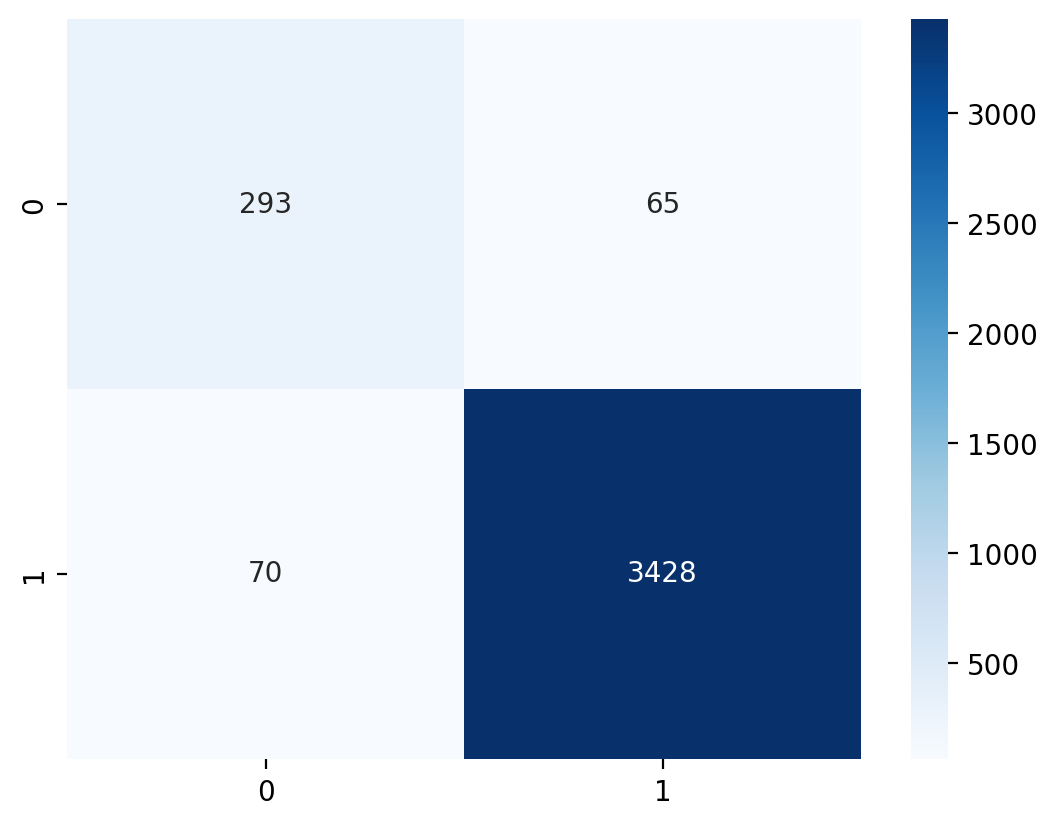

In [118]:
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')


### (3) 모델 3: Dropout

- 모델을 선언합니다.

In [119]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x.shape[1]

# Sequential 모델 선언
model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,481 (80.00 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [120]:
# 학습 설정 => 분류모델이기에 정확성으로
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [121]:
# 이미 나눈 x_val, y_val을 검증셋으로 직접 전달
hist = model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=32, # 보통 32나 64 설정
                 validation_data=(x_val, y_val), # 분리해둔 데이터를 그대로 사용
                 verbose=1) # 학습 과정을 보기 위해 1로 설정 추천

Epoch 1/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9040 - loss: 0.2434 - val_accuracy: 0.9336 - val_loss: 0.1477
Epoch 2/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9411 - loss: 0.1555 - val_accuracy: 0.9541 - val_loss: 0.1166
Epoch 3/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9533 - loss: 0.1314 - val_accuracy: 0.9598 - val_loss: 0.1026
Epoch 4/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9584 - loss: 0.1185 - val_accuracy: 0.9647 - val_loss: 0.0960
Epoch 5/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9612 - loss: 0.1132 - val_accuracy: 0.9689 - val_loss: 0.0897
Epoch 6/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9650 - loss: 0.0979 - val_accuracy: 0.9660 - val_loss: 0.0976
Epoch 7/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9660 - loss: 0.0966 - val_accuracy: 0.9686 - val_loss: 0.0856
Epoch 8/50
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9678 - loss: 0.0900 - val_accuracy: 0.

- 학습 곡선을 확인합니다.

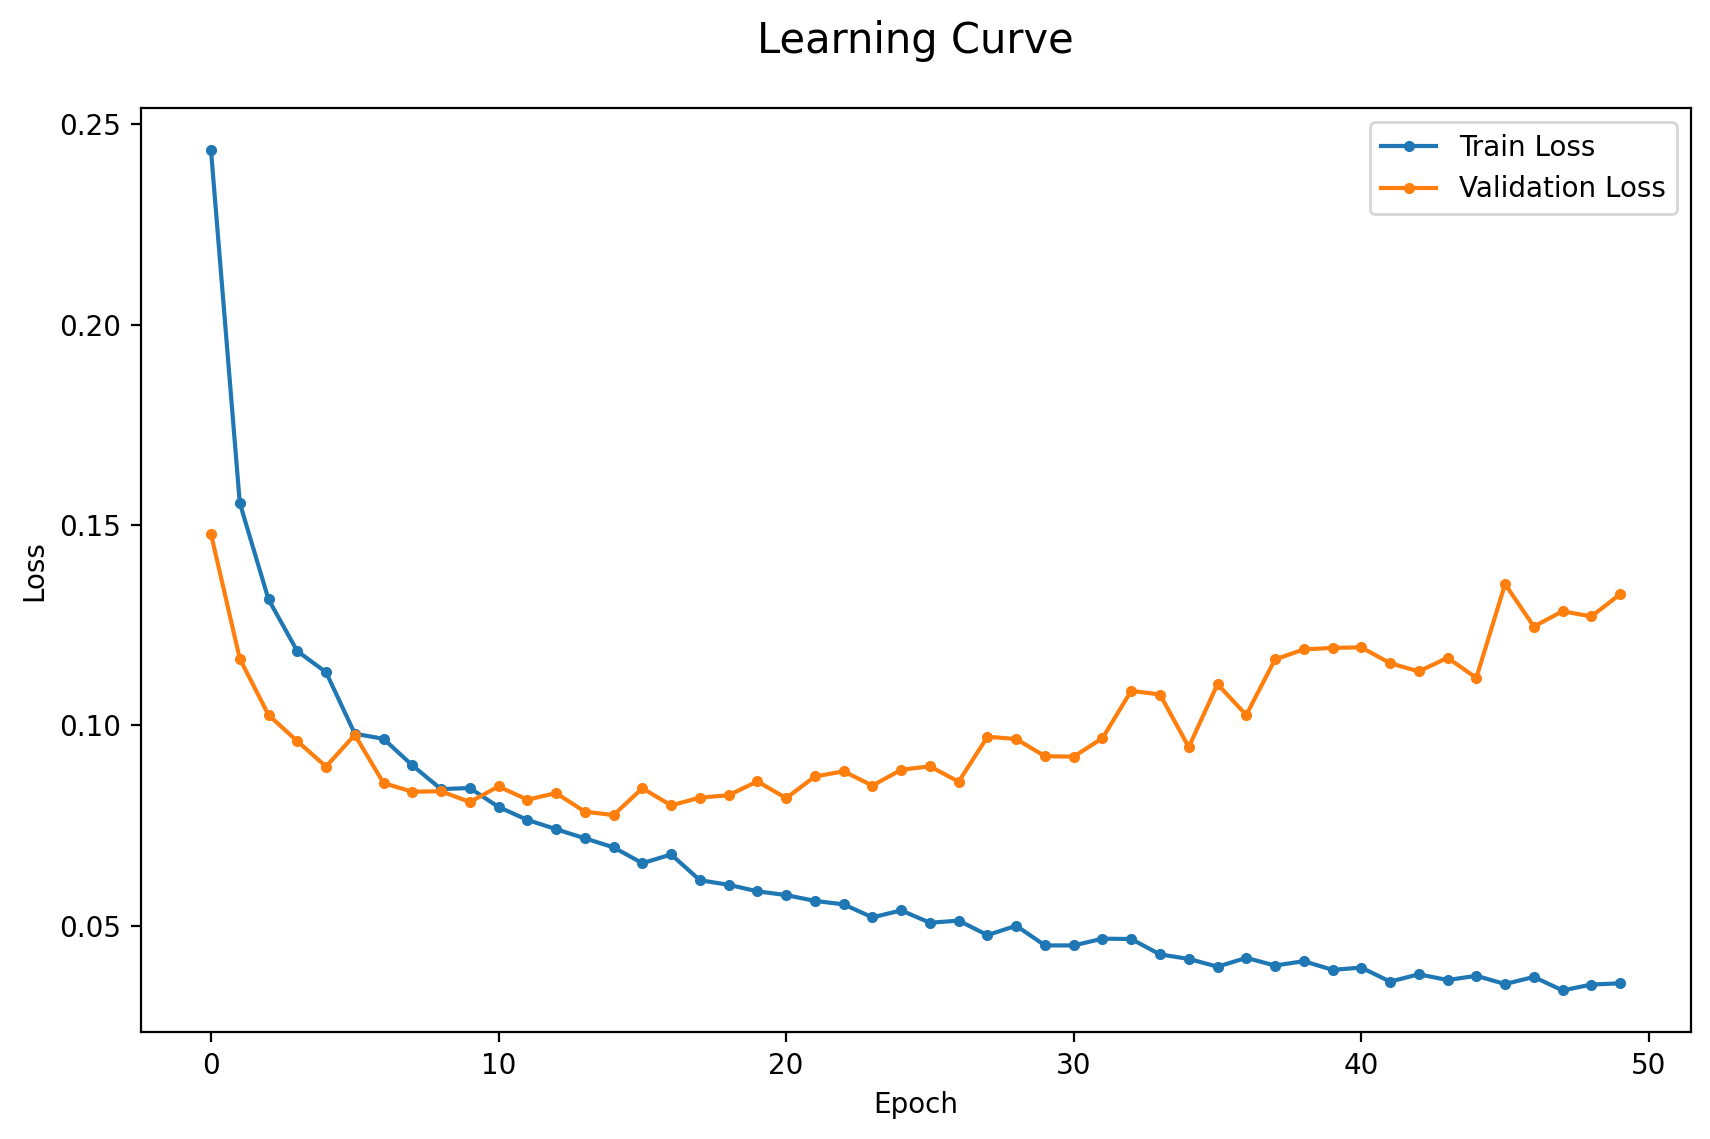

In [122]:
# 학습 곡선
dl_history_plot(hist.history)

- 검증 데이터로 예측을 수행하고 성능을 확인합니다.

In [ ]:
# 확률값 --> 0, 1 변환
y_pred = (y_pred > 0.5).astype('int')

# y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       358
           1       0.98      0.98      0.98      3498

    accuracy                           0.96      3856
   macro avg       0.89      0.90      0.90      3856
weighted avg       0.97      0.96      0.97      3856



### (4) 모델 4: Early Stopping

- 모델을 선언합니다.

In [124]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x.shape[1]

# Sequential 모델 선언
model4 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,481 (80.00 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [125]:
# 학습 설정
model4.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

In [126]:
# 1. 클래스 가중치 설정 (불만족 0번에 10배 중요도 부여)
class_weights = {0: 10.0, 1: 1.0}

# 2. 모델 학습 (검증 데이터와 가중치 통합)
hist = model4.fit(x_train, y_train,
                 epochs=50,
                 batch_size=64,              # 곡선을 매끄럽게 하기 위해 64 추천
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 class_weight=class_weights,    # 불균형 해소를 위한 가중치 적용
                 verbose=1)


Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7314 - loss: 0.9476 - val_accuracy: 0.8613 - val_loss: 0.3162
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8618 - loss: 0.5664 - val_accuracy: 0.8797 - val_loss: 0.2836
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8806 - loss: 0.4831 - val_accuracy: 0.9007 - val_loss: 0.2268
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8935 - loss: 0.4370 - val_accuracy: 0.9227 - val_loss: 0.1800
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9016 - loss: 0.4055 - val_accuracy: 0.9126 - val_loss: 0.2079
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.3761 - val_accuracy: 0.9095 - val_loss: 0.2126
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9125 - loss: 0.3610 - val_accuracy: 0.9261 - val_loss: 0.1662
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9174 - loss: 0.3426 - val_accuracy: 0.

- 학습 곡선을 확인합니다.

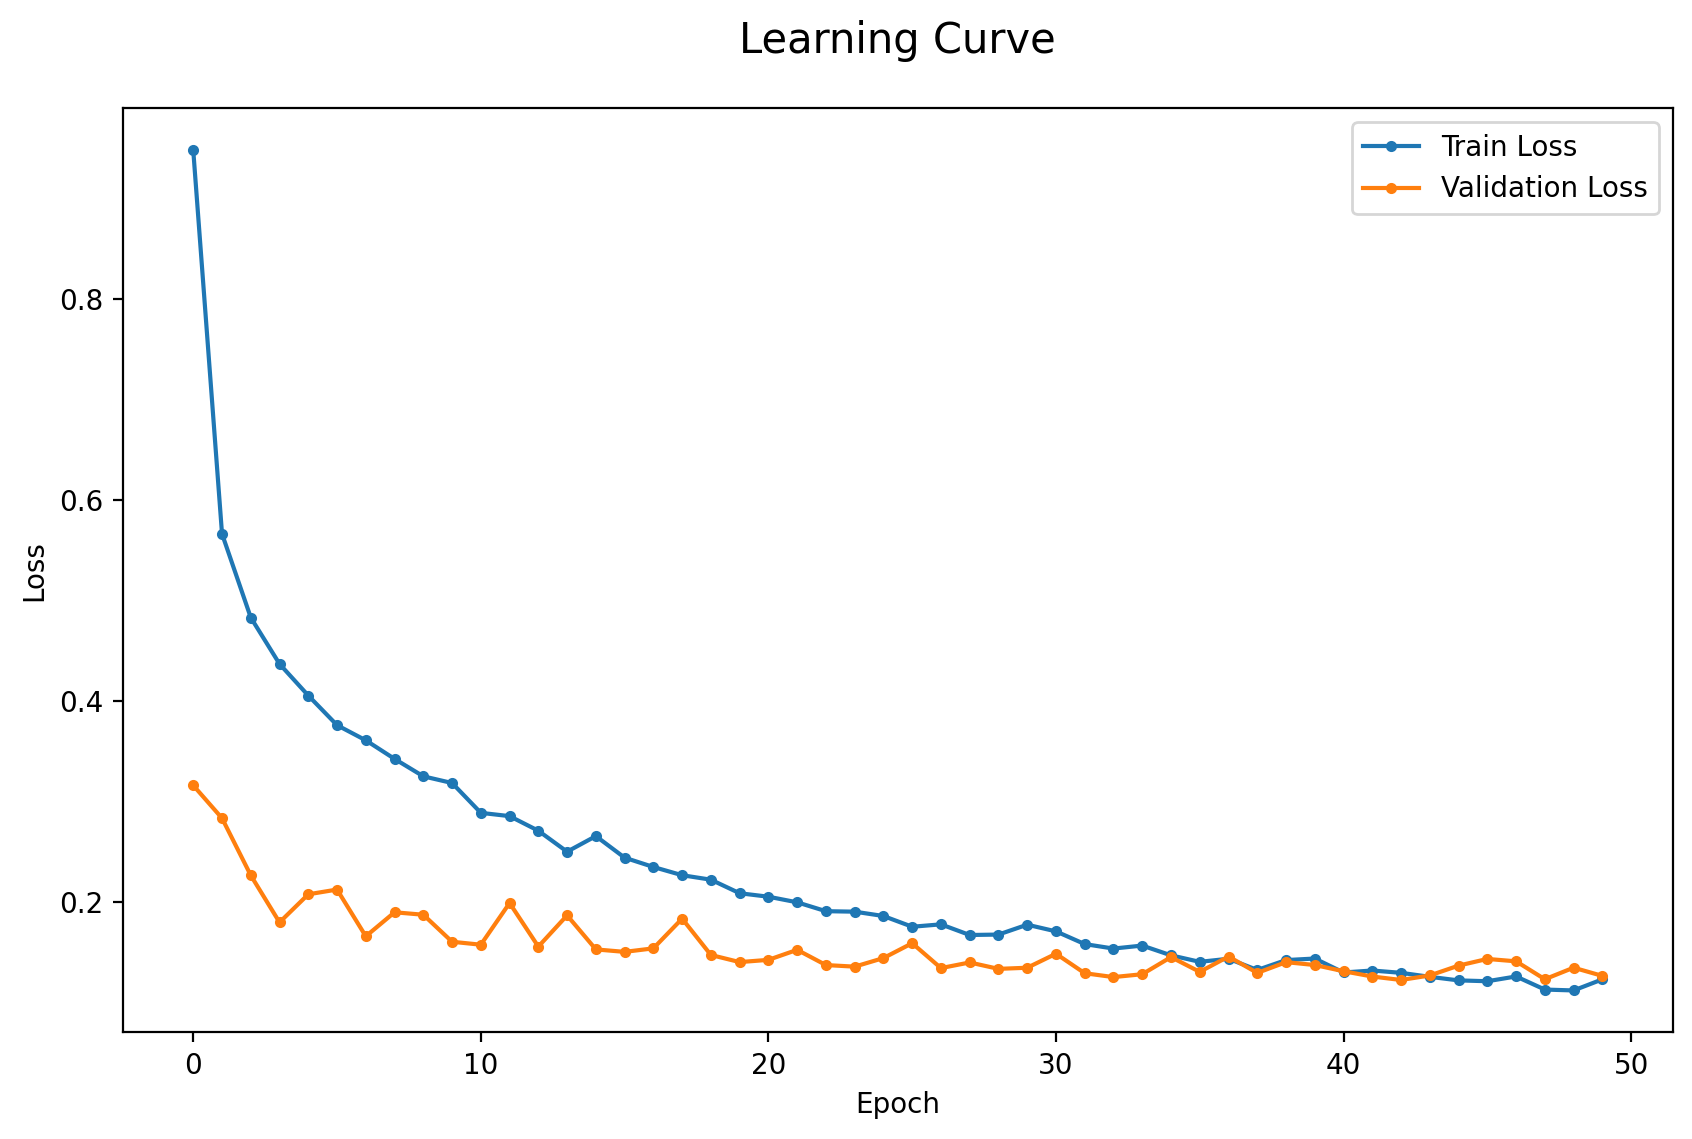

In [127]:
# 학습 곡선
dl_history_plot(hist.history)

In [128]:
# 예측
y_pred = model4.predict(x_val)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


- 검증 데이터로 예측 및 평가를 수행합니다.

In [129]:
# 확률값 --> 0, 1 변환
y_pred = (y_pred > 0.5).astype('int')

# y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.69      0.90      0.78       358
           1       0.99      0.96      0.97      3498

    accuracy                           0.95      3856
   macro avg       0.84      0.93      0.88      3856
weighted avg       0.96      0.95      0.96      3856



<Axes: >

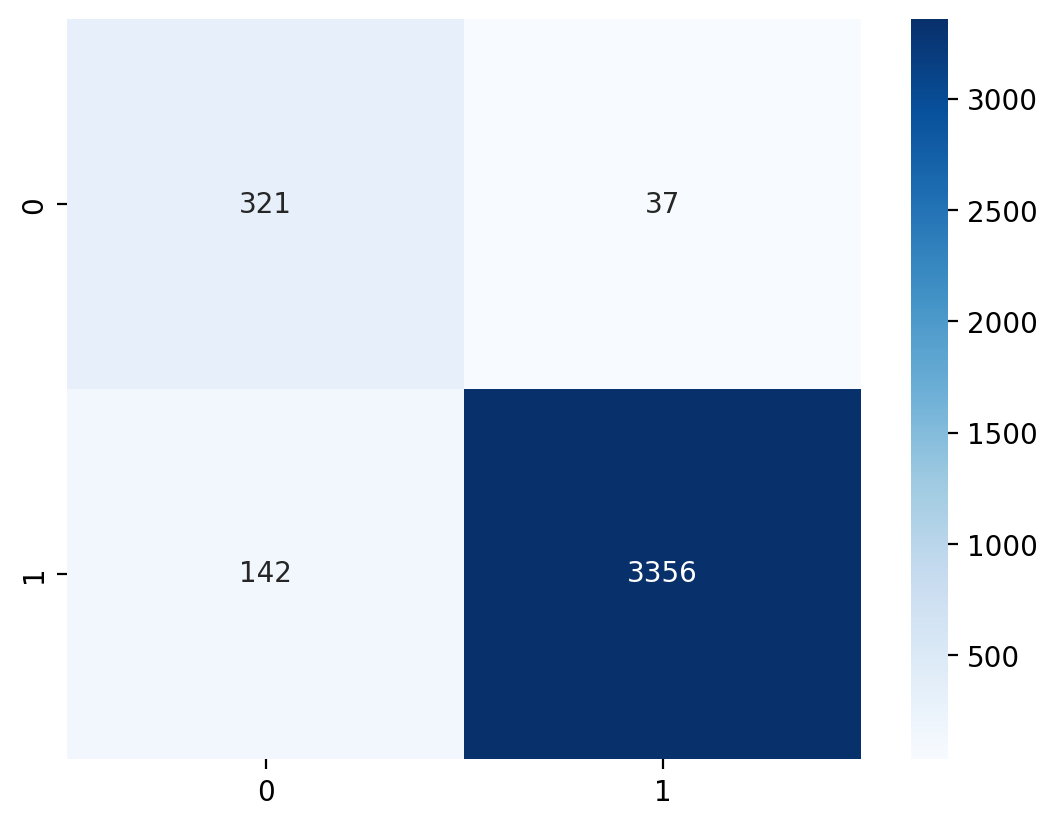

In [130]:
# 혼돈행렬
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')

### (5) 저장

- 학습용 데이터 스케일링에 사용한 스케일러를 **scaler.pkl** 파일로 저장합니다.
- **joblib.dump()** 함수를 사용합니다.

In [131]:
# 스케일러 저장
joblib.dump(scaler, path + 'scaler.pkl')

['/content/drive/MyDrive/project01/scaler.pkl']

- 성능이 가장 높은 모델을 **base_model.keras** 파일로 저장합니다.
- **save()** 메서드를 사용합니다.

In [132]:
# 모델 저장
model4.save(path + 'base_model.keras')